# Depth Prediction on Amazon Data using Finetuned GLP-Depth

This notebook runs inference on a few examples from the Amazon product dataset using the GLP-Depth model finetuned on **ShapeNetSem Normalized**.

**Pipeline (from the paper):**
1. Load finetuned checkpoint (`best_model_cosine_adamw.ckpt`)
2. For each Amazon product image: resize to 480×480, pad to 480×640 (white borders)
3. Model predicts **normalized depth** (depth / diagonal_norm)
4. De-normalize by multiplying with physical diagonal norm (dimensions → meters)
5. Mask out white background pixels using thresholding

In [3]:
import os
import sys
import cv2
import numpy as np
import pickle
import lz4.block
from io import BytesIO
from PIL import Image
from collections import OrderedDict

import torch
import matplotlib.pyplot as plt

# Add code directory to path so we can import the model
sys.path.insert(0, os.path.join(os.getcwd(), 'code'))

from models.model import GLPDepth

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 8)

print("Imports OK")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/Users/manuel.curnis/GLPDepth-Edited/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK
PyTorch version: 2.11.0
CUDA available: False
Using device: cpu


/Users/manuel.curnis/GLPDepth-Edited/.venv/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/manuel.curnis/GLPDepth-Edited/.venv/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


## 1. Load Finetuned Model

Load the GLP-Depth model with `max_depth=2.63` (matching ShapeNetSem Normalized training) and the finetuned checkpoint.

In [4]:
# Model config - must match training settings
MAX_DEPTH = 2.63  # ShapeNetSem Normalized max depth
CKPT_PATH = './code/models/best_model_cosine_adamw.ckpt'

# Load model
model = GLPDepth(max_depth=MAX_DEPTH, is_train=False).to(device)

# Load checkpoint (handle DataParallel 'module.' prefix if present)
model_weight = torch.load(CKPT_PATH, map_location=device)
if 'module' in next(iter(model_weight.items()))[0]:
    model_weight = OrderedDict((k[7:], v) for k, v in model_weight.items())
model.load_state_dict(model_weight)
model.eval()

print(f"Model loaded from: {CKPT_PATH}")
print(f"Max depth: {MAX_DEPTH}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded from: ./code/models/best_model_cosine_adamw.ckpt
Max depth: 2.63
Total parameters: 61,220,903


## 2. Helper Functions

Functions to load `.pklz` files, preprocess images, compute normalization, and crop/mask predictions.

In [5]:
import torchvision.transforms as transforms
to_tensor = transforms.ToTensor()

def load_pklz(filepath):
    """Load a compressed .pklz Amazon product record."""
    with open(filepath, 'rb') as fp:
        compressed_bytes = fp.read()
    decompressed = lz4.block.decompress(compressed_bytes)
    return pickle.loads(decompressed)

def unpack_image(binary_image_data):
    """Decode binary image data to numpy array (RGB)."""
    image = Image.open(BytesIO(binary_image_data))
    return np.array(image)

def resize_and_pad(image):
    """Resize to 480x480 and pad to 480x640 with white borders (matching ShapeNetSem format)."""
    border_size = (640 - 480) // 2
    image = cv2.resize(image, (480, 480))
    image = cv2.copyMakeBorder(image, 0, 0, border_size, border_size,
                               cv2.BORDER_CONSTANT, value=[255, 255, 255])
    return image

def get_normalization(dimensions_str):
    """Convert dimension strings (inches) to normalization factor (L2 norm in meters)."""
    dims = np.array([float(d) for d in dimensions_str])
    dims_meters = dims * 2.54 / 100.0  # inches → cm → meters
    return np.linalg.norm(dims_meters)

def crop_prediction(pred, input_image):
    """Mask out background (white) pixels from prediction using thresholding."""
    gray = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)
    _, bin_img = cv2.threshold(gray, 253, 255, cv2.THRESH_BINARY_INV)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    bin_img = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel, iterations=2)
    
    valid_mask = torch.from_numpy(bin_img > (255 / 2)).to(device=pred.device)
    
    # Evaluation region mask
    eval_mask = torch.zeros(valid_mask.shape).to(device=valid_mask.device)
    eval_mask[45:471, 41:601] = 1
    valid_mask = torch.logical_and(valid_mask, eval_mask)
    
    zeros = torch.zeros_like(pred)
    return torch.where(valid_mask, pred, zeros)

print("Helper functions defined.")

Helper functions defined.


## 3. Load a Few Amazon Test Samples

Pick 5 diverse examples from the test set to demonstrate inference.

In [6]:
TEST_DIR = './datasets/amazon_data/test_data'

# Get all .pklz files (exclude subdirectories like glpn_depth/)
all_files = sorted([
    f for f in os.listdir(TEST_DIR) 
    if f.endswith('.pklz')
])
print(f"Total test samples: {len(all_files)}")

# Pick 5 evenly spaced examples for a diverse preview
NUM_EXAMPLES = 5
indices = np.linspace(0, len(all_files) - 1, NUM_EXAMPLES, dtype=int)
sample_files = [all_files[i] for i in indices]

print(f"\nSelected samples:")
for f in sample_files:
    print(f"  - {f}")

Total test samples: 1435

Selected samples:
  - 6530_ignition coil large.pklz
  - 6888_cooking pan curved.pklz
  - 7247_clapperboard brand name.pklz
  - 7605_mute purple.pklz
  - 7964_butter knife skiny.pklz


## 4. Run Inference on Selected Samples

For each sample:
1. Load image & dimensions from `.pklz`
2. Preprocess image (resize + pad)
3. Run model forward pass → normalized depth
4. De-normalize: `pred_depth = model_output × normalization_factor`
5. Convert to mm, mask out background

In [7]:
results = []

for fname in sample_files:
    filepath = os.path.join(TEST_DIR, fname)
    
    # Load data
    record = load_pklz(filepath)
    raw_image = unpack_image(record['image_data'])
    dimensions = record['dimensions']
    weight = record.get('weight', 'N/A')
    
    # Preprocess
    image = resize_and_pad(raw_image)
    normalization = get_normalization(dimensions)
    
    # To tensor and run inference
    image_tensor = to_tensor(image).unsqueeze(0).to(device)  # (1, 3, 480, 640)
    
    with torch.no_grad():
        pred = model(image_tensor)
    
    # De-normalize: model predicts depth/diagonal_norm, multiply back
    pred_d = pred['pred_d'].squeeze() * normalization
    
    # Convert to mm
    pred_d_mm = pred_d * 1000.0
    
    # Mask out background
    pred_d_mm = crop_prediction(pred_d_mm, image)
    pred_d_np = pred_d_mm.cpu().numpy()
    
    # Store results
    dims_str = ' × '.join(dimensions) + ' inches'
    results.append({
        'filename': fname,
        'raw_image': raw_image,
        'processed_image': image,
        'depth_pred': pred_d_np,
        'dimensions': dims_str,
        'normalization': normalization,
        'weight': weight
    })
    
    print(f"✓ {fname[:50]:<50s} | dims: {dims_str:<30s} | norm: {normalization:.4f}m | weight: {weight}")

print(f"\nInference complete on {len(results)} samples.")

/var/folders/w8/l3b5rp5n4vqdlhzzjgztff500000gq/T/ipykernel_8896/587965541.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.loads(decompressed)


✓ 6530_ignition coil large.pklz                      | dims: 4.00 × 4.00 × 4.00 inches      | norm: 0.1760m | weight: 2.00
✓ 6888_cooking pan curved.pklz                       | dims: 22.80 × 11.00 × 1.60 inches    | norm: 0.6443m | weight: 4.00
✓ 7247_clapperboard brand name.pklz                  | dims: 18.00 × 12.00 × 6.00 inches    | norm: 0.5702m | weight: 0.60
✓ 7605_mute purple.pklz                              | dims: 4.20 × 3.70 × 1.20 inches      | norm: 0.1454m | weight: 0.31
✓ 7964_butter knife skiny.pklz                       | dims: 7.50 × 1.50 × 0.80 inches      | norm: 0.1953m | weight: 0.15

Inference complete on 5 samples.


## 5. Visualize Results

For each sample, show:
- **Left**: Original product image  
- **Center**: Processed image (resized + padded to 480×640)
- **Right**: Predicted depth map (in mm, background masked)

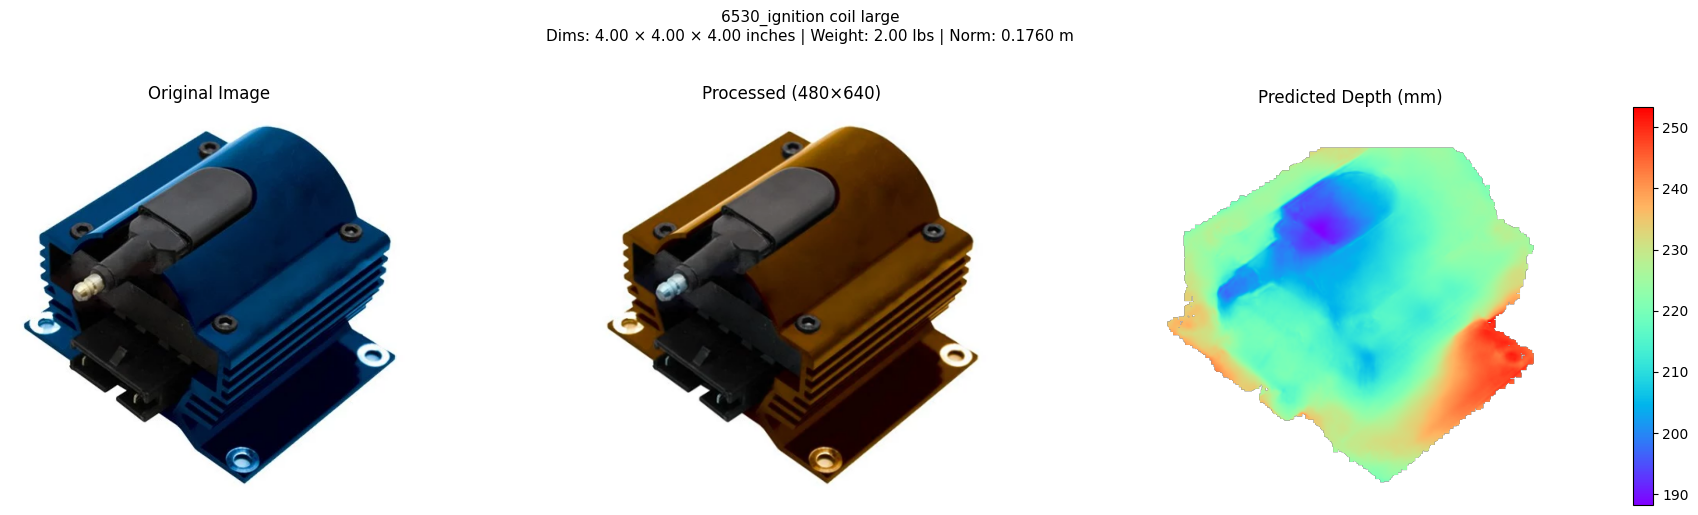

  Depth range (non-zero): 188.3 – 253.3 mm



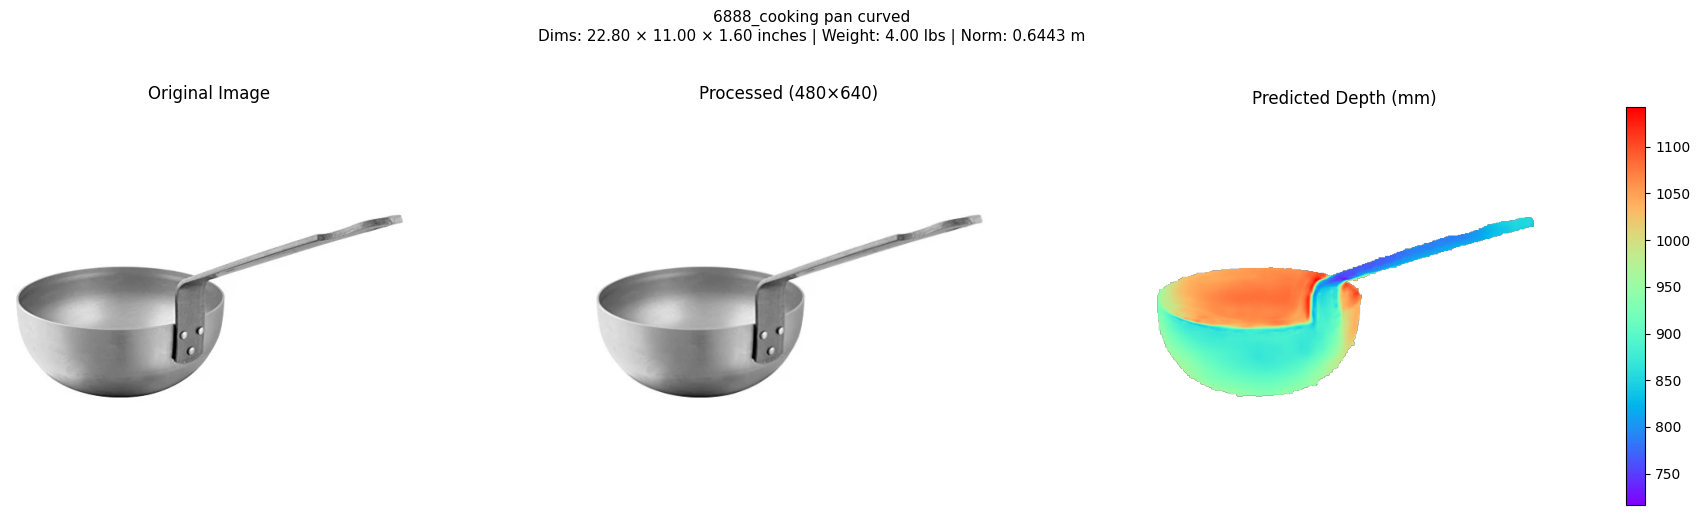

  Depth range (non-zero): 716.5 – 1142.4 mm



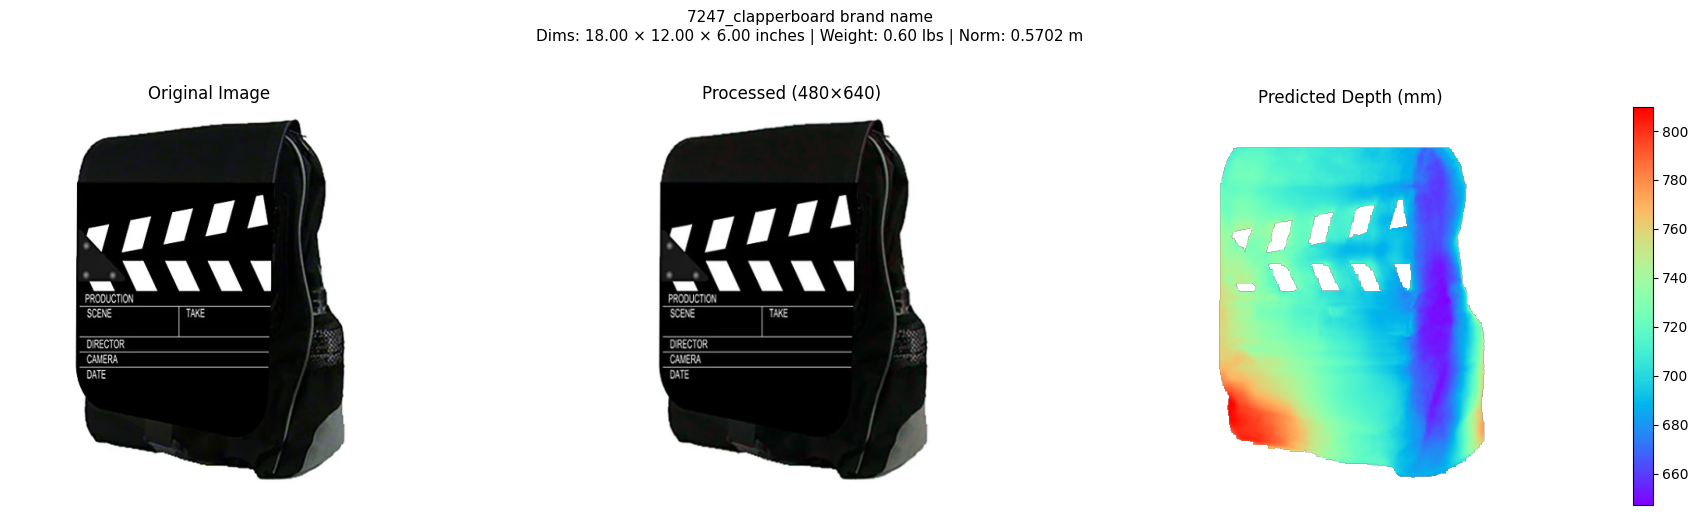

  Depth range (non-zero): 647.2 – 809.8 mm



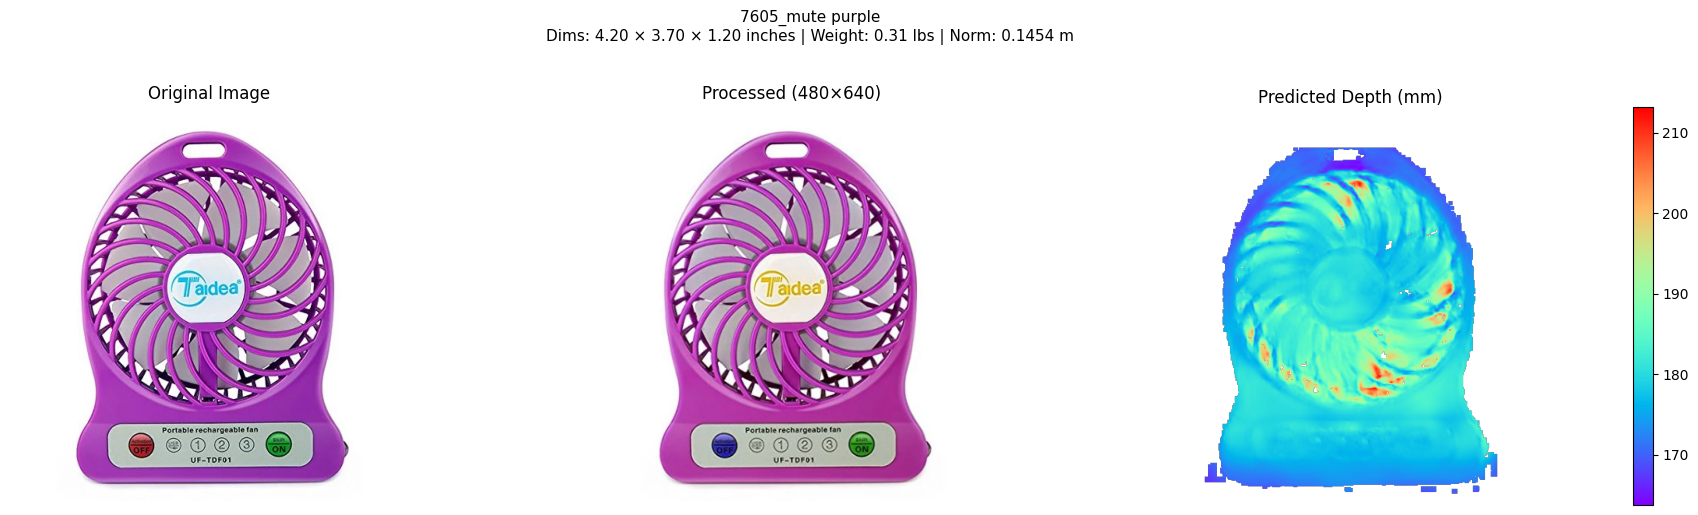

  Depth range (non-zero): 163.7 – 213.2 mm



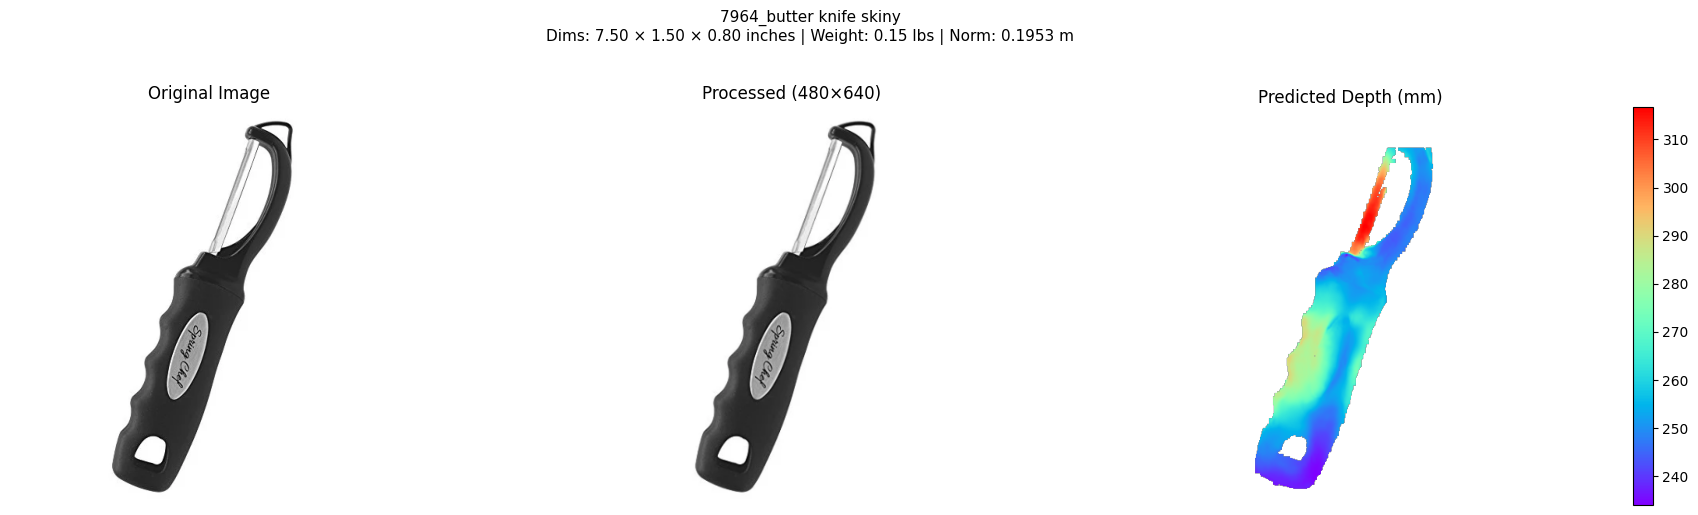

  Depth range (non-zero): 234.0 – 316.8 mm



In [8]:
for i, r in enumerate(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Original image
    axes[0].imshow(r['raw_image'])
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')
    
    # Processed image (what the model sees)
    axes[1].imshow(cv2.cvtColor(r['processed_image'], cv2.COLOR_BGR2RGB))
    axes[1].set_title('Processed (480×640)', fontsize=12)
    axes[1].axis('off')
    
    # Depth prediction
    depth = r['depth_pred']
    # Mask zeros for better colormap visualization
    depth_masked = np.ma.masked_where(depth == 0, depth)
    im = axes[2].imshow(depth_masked, cmap='rainbow')
    axes[2].set_title('Predicted Depth (mm)', fontsize=12)
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    
    # Title with product info
    short_name = r['filename'].replace('.pklz', '')
    fig.suptitle(
        f"{short_name}\nDims: {r['dimensions']} | Weight: {r['weight']} lbs | Norm: {r['normalization']:.4f} m",
        fontsize=11, y=1.02
    )
    
    plt.tight_layout()
    plt.show()
    print(f"  Depth range (non-zero): {depth[depth > 0].min():.1f} – {depth[depth > 0].max():.1f} mm\n")

## 6. Depth Statistics Summary

Quick summary of predicted depth statistics for each sample.

In [9]:
print(f"{'Product':<55s} {'Min (mm)':>10s} {'Mean (mm)':>10s} {'Max (mm)':>10s} {'Norm (m)':>10s}")
print("─" * 100)
for r in results:
    d = r['depth_pred']
    nonzero = d[d > 0]
    name = r['filename'].replace('.pklz', '')[:52]
    if len(nonzero) > 0:
        print(f"{name:<55s} {nonzero.min():>10.1f} {nonzero.mean():>10.1f} {nonzero.max():>10.1f} {r['normalization']:>10.4f}")
    else:
        print(f"{name:<55s} {'N/A':>10s} {'N/A':>10s} {'N/A':>10s} {r['normalization']:>10.4f}")

Product                                                   Min (mm)  Mean (mm)   Max (mm)   Norm (m)
────────────────────────────────────────────────────────────────────────────────────────────────────
6530_ignition coil large                                     188.3      219.6      253.3     0.1760
6888_cooking pan curved                                      716.5      948.6     1142.4     0.6443
7247_clapperboard brand name                                 647.2      709.3      809.8     0.5702
7605_mute purple                                             163.7      179.8      213.2     0.1454
7964_butter knife skiny                                      234.0      259.9      316.8     0.1953
